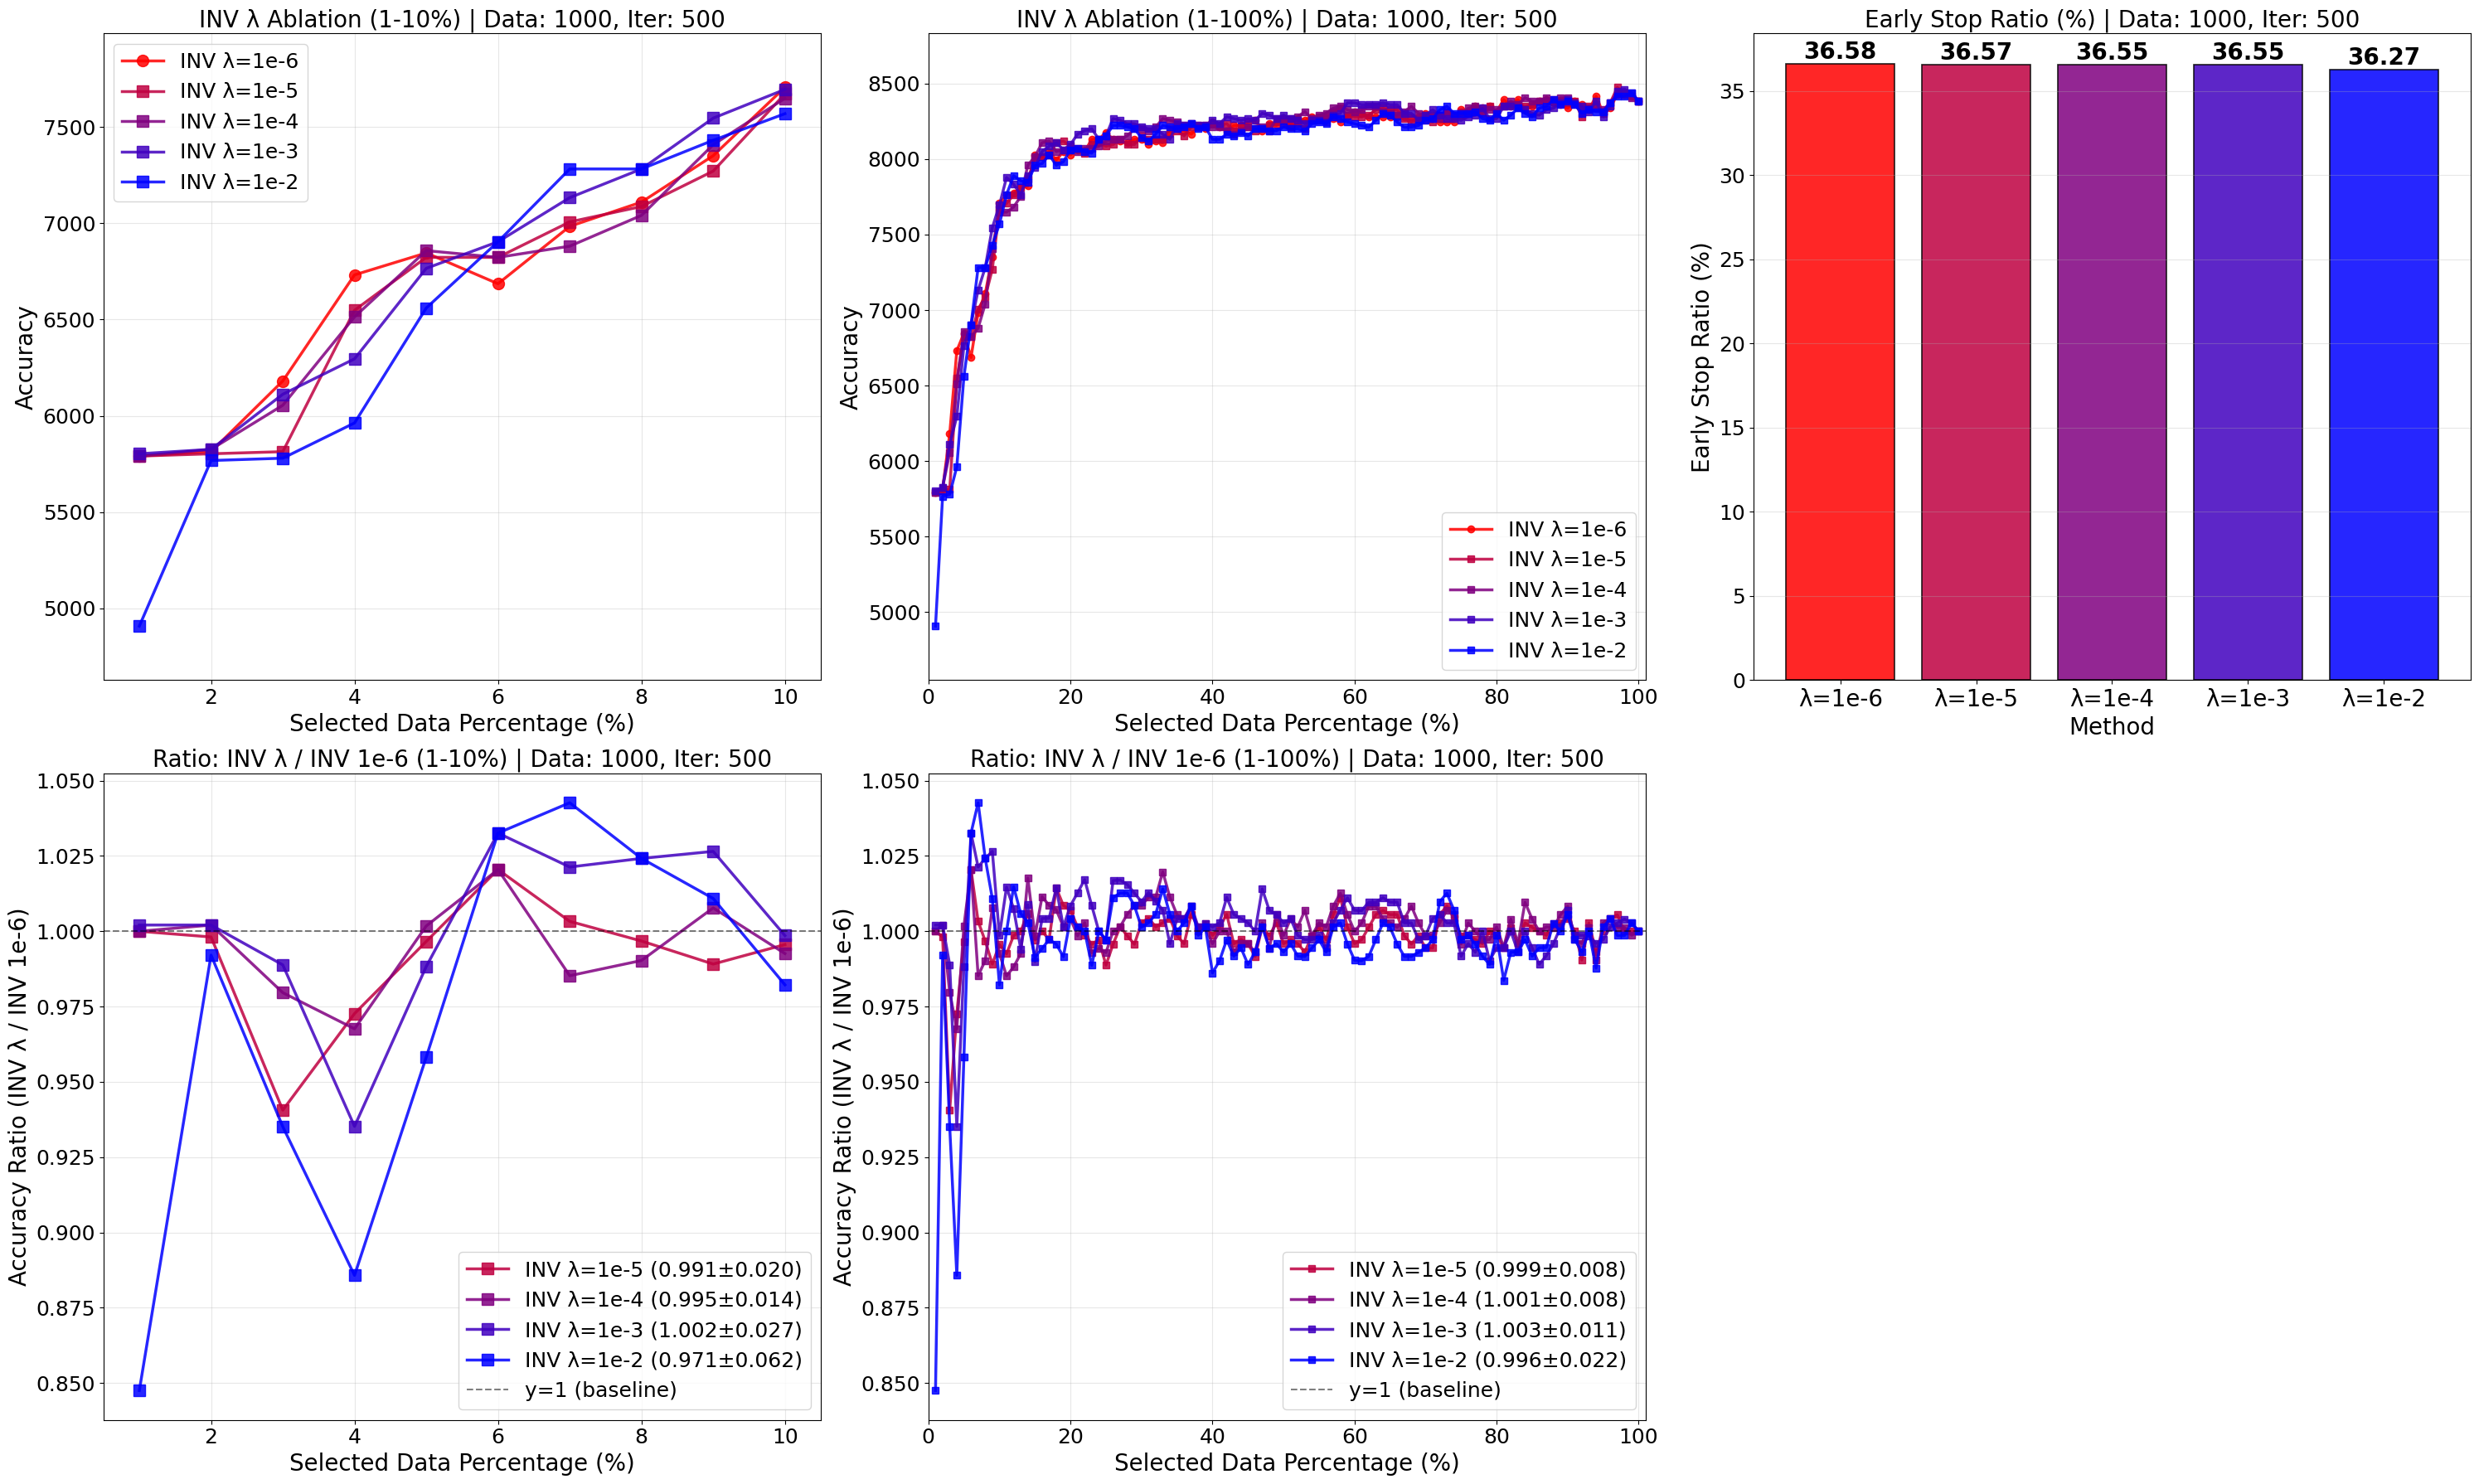

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 1000
iteration = 500
rank = 5
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [5791, 5814, 6181, 6732, 6846, 6686, 6984, 7110, 7351, 7706, 7764, 7775, 7810, 7821, 8028, 8016, 8050, 7993, 8050, 8028, 8062, 8050, 8131, 8131, 8177, 8131, 8119, 8108, 8131, 8131, 8096, 8119, 8108, 8165, 8200, 8188, 8165, 8211, 8200, 8245, 8211, 8188, 8222, 8222, 8245, 8257, 8188, 8234, 8222, 8268, 8234, 8268, 8257, 8280, 8268, 8291, 8268, 8245, 8280, 8314, 8303, 8280, 8280, 8280, 8280, 8280, 8280, 8280, 8280, 8303, 8291, 8245, 8245, 8245, 8326, 8314, 8349, 8337, 8349, 8314, 8394, 8349, 8394, 8326, 8349, 8383, 8394, 8372, 8360, 8337, 8383, 8360, 8326, 8417, 8303, 8337, 8429, 8429, 8417, 8383]
lam1e_5  = [5791, 5803, 5814, 6548, 6823, 6823, 7007, 7087, 7271, 7672, 7706, 7764, 7810, 7867, 8005, 8016, 8028, 8108, 8119, 8085, 8073, 8039, 8096, 8108, 8085, 8096, 8131, 8096, 8096, 8154, 8131, 8131, 8131, 8200, 8188, 8154, 8211, 8222, 8222, 8234, 8222, 8234, 8188, 8200, 8211, 8188, 8200, 8222, 8245, 8234, 8211, 8234, 8200, 8268, 8280, 8268, 8314, 8337, 8291, 8280, 8280, 8291, 8326, 8337, 8326, 8326, 8268, 8245, 8268, 8257, 8245, 8291, 8314, 8280, 8314, 8303, 8326, 8303, 8349, 8303, 8349, 8360, 8360, 8349, 8360, 8383, 8383, 8394, 8383, 8372, 8383, 8280, 8349, 8360, 8303, 8372, 8475, 8429, 8417, 8383]
lam1e_4  = [5791, 5826, 6055, 6514, 6858, 6823, 6881, 7041, 7408, 7649, 7649, 7683, 7752, 7959, 8016, 8108, 8119, 8050, 8062, 8062, 8050, 8073, 8073, 8085, 8119, 8131, 8131, 8154, 8200, 8200, 8188, 8211, 8268, 8257, 8245, 8222, 8234, 8211, 8211, 8211, 8211, 8188, 8165, 8188, 8211, 8200, 8211, 8188, 8268, 8257, 8268, 8280, 8314, 8268, 8291, 8303, 8337, 8349, 8326, 8314, 8326, 8349, 8349, 8314, 8303, 8291, 8314, 8349, 8303, 8291, 8280, 8268, 8303, 8291, 8291, 8337, 8349, 8314, 8326, 8326, 8349, 8383, 8360, 8406, 8383, 8383, 8406, 8383, 8406, 8406, 8360, 8326, 8337, 8337, 8326, 8372, 8440, 8440, 8406, 8383]
lam1e_3  = [5803, 5826, 6112, 6296, 6766, 6904, 7133, 7282, 7546, 7695, 7878, 7833, 7764, 7890, 7947, 8050, 8085, 8108, 8062, 8096, 8165, 8188, 8200, 8131, 8154, 8268, 8257, 8234, 8234, 8211, 8200, 8200, 8165, 8131, 8234, 8222, 8234, 8222, 8222, 8257, 8234, 8280, 8268, 8257, 8268, 8257, 8303, 8291, 8268, 8291, 8268, 8257, 8234, 8257, 8257, 8245, 8291, 8303, 8372, 8372, 8360, 8360, 8360, 8372, 8360, 8360, 8303, 8303, 8257, 8291, 8326, 8291, 8268, 8268, 8257, 8280, 8291, 8337, 8268, 8268, 8349, 8349, 8337, 8326, 8303, 8291, 8326, 8337, 8372, 8394, 8372, 8349, 8314, 8383, 8280, 8349, 8452, 8463, 8440, 8383]
lam1e_2  = [4908, 5768, 5780, 5963, 6560, 6904, 7282, 7282, 7431, 7569, 7764, 7890, 7856, 7844, 7959, 7970, 8028, 7959, 7982, 8062, 8073, 8050, 8039, 8131, 8154, 8222, 8222, 8211, 8200, 8142, 8119, 8165, 8222, 8211, 8200, 8211, 8234, 8200, 8211, 8131, 8131, 8165, 8154, 8177, 8154, 8200, 8200, 8188, 8188, 8211, 8200, 8200, 8188, 8234, 8245, 8234, 8280, 8268, 8245, 8234, 8222, 8211, 8257, 8303, 8291, 8245, 8211, 8211, 8222, 8257, 8268, 8326, 8349, 8303, 8303, 8303, 8314, 8268, 8257, 8303, 8257, 8291, 8337, 8303, 8280, 8337, 8349, 8394, 8360, 8383, 8360, 8303, 8326, 8314, 8314, 8372, 8417, 8417, 8440, 8383]

lam1e_6_early_stop = [36.58]
lam1e_5_early_stop = [36.57]
lam1e_4_early_stop = [36.55]
lam1e_3_early_stop = [36.55]
lam1e_2_early_stop = [36.27]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

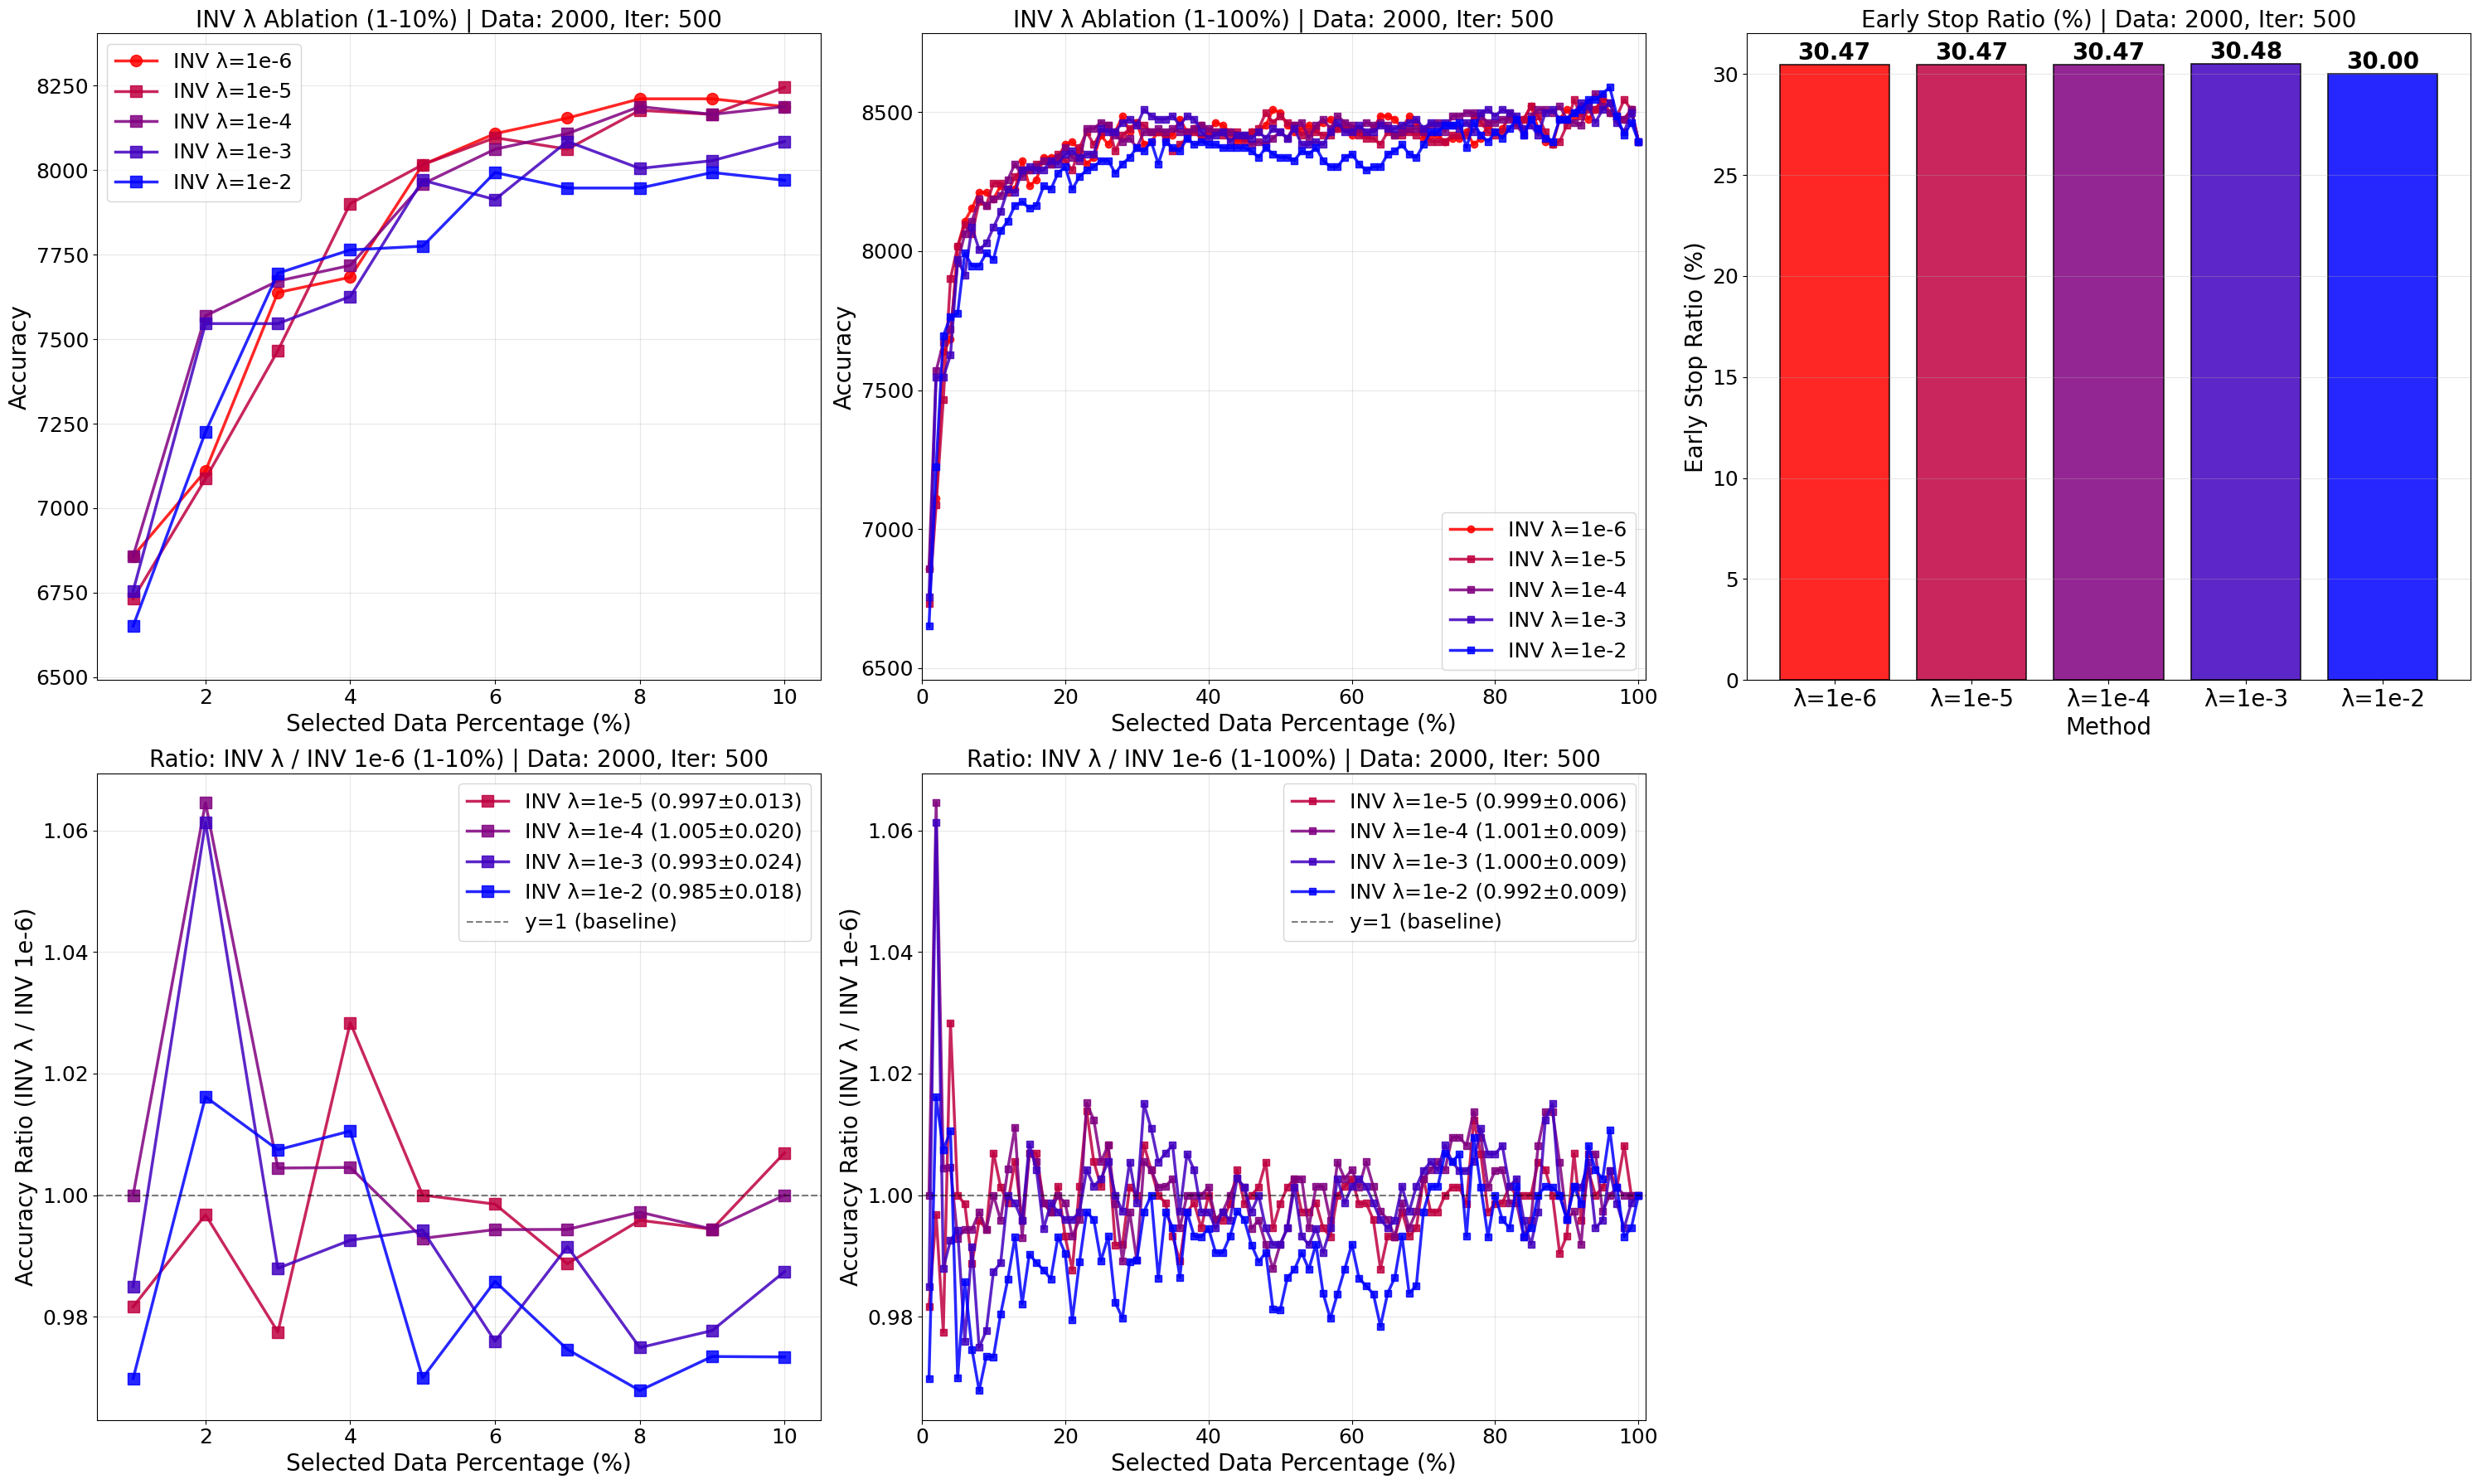

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 2000
iteration = 500
rank = 5
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [6858, 7110, 7638, 7683, 8016, 8108, 8154, 8211, 8211, 8188, 8234, 8222, 8222, 8326, 8234, 8257, 8337, 8337, 8337, 8383, 8394, 8360, 8314, 8337, 8417, 8383, 8429, 8486, 8429, 8463, 8383, 8394, 8429, 8417, 8417, 8475, 8429, 8440, 8452, 8429, 8463, 8452, 8429, 8394, 8406, 8429, 8429, 8452, 8509, 8498, 8452, 8429, 8440, 8452, 8440, 8463, 8475, 8440, 8440, 8417, 8429, 8417, 8440, 8486, 8486, 8475, 8440, 8486, 8463, 8406, 8417, 8417, 8394, 8406, 8406, 8429, 8383, 8406, 8452, 8429, 8440, 8486, 8463, 8475, 8521, 8440, 8394, 8383, 8475, 8509, 8486, 8521, 8475, 8509, 8544, 8498, 8475, 8475, 8509, 8394]
lam1e_5  = [6732, 7087, 7466, 7901, 8016, 8096, 8062, 8177, 8165, 8245, 8245, 8211, 8268, 8291, 8291, 8314, 8326, 8314, 8349, 8326, 8291, 8372, 8429, 8383, 8429, 8452, 8360, 8417, 8440, 8463, 8452, 8429, 8429, 8406, 8360, 8383, 8406, 8429, 8406, 8429, 8429, 8417, 8417, 8429, 8394, 8429, 8440, 8498, 8463, 8486, 8463, 8452, 8417, 8429, 8429, 8417, 8417, 8440, 8452, 8440, 8417, 8406, 8406, 8383, 8429, 8417, 8417, 8429, 8417, 8429, 8394, 8394, 8394, 8417, 8417, 8417, 8486, 8463, 8429, 8417, 8429, 8498, 8463, 8475, 8521, 8486, 8429, 8383, 8394, 8452, 8544, 8486, 8509, 8509, 8555, 8532, 8486, 8544, 8509, 8394]
lam1e_4  = [6858, 7569, 7672, 7718, 7959, 8062, 8108, 8188, 8165, 8188, 8200, 8257, 8314, 8268, 8291, 8303, 8326, 8314, 8337, 8372, 8337, 8326, 8440, 8440, 8463, 8452, 8417, 8394, 8406, 8372, 8429, 8429, 8440, 8429, 8440, 8429, 8429, 8440, 8452, 8440, 8429, 8429, 8429, 8417, 8417, 8383, 8394, 8383, 8406, 8429, 8406, 8452, 8463, 8406, 8452, 8475, 8440, 8486, 8463, 8452, 8440, 8463, 8452, 8463, 8452, 8417, 8429, 8440, 8440, 8429, 8452, 8463, 8429, 8486, 8486, 8498, 8498, 8486, 8463, 8463, 8475, 8475, 8452, 8417, 8486, 8509, 8509, 8498, 8521, 8475, 8463, 8452, 8532, 8567, 8521, 8498, 8486, 8475, 8509, 8394]
lam1e_3  = [6755, 7546, 7546, 7626, 7970, 7913, 8085, 8005, 8028, 8085, 8142, 8222, 8211, 8291, 8303, 8291, 8291, 8326, 8314, 8349, 8360, 8337, 8349, 8349, 8440, 8429, 8429, 8463, 8475, 8452, 8509, 8486, 8475, 8475, 8486, 8452, 8486, 8475, 8429, 8406, 8417, 8429, 8394, 8417, 8417, 8406, 8429, 8406, 8440, 8429, 8406, 8440, 8383, 8383, 8394, 8383, 8429, 8463, 8429, 8429, 8452, 8429, 8429, 8452, 8440, 8440, 8452, 8463, 8475, 8440, 8463, 8452, 8463, 8452, 8440, 8463, 8429, 8498, 8509, 8486, 8509, 8498, 8486, 8440, 8452, 8417, 8498, 8509, 8475, 8475, 8498, 8532, 8521, 8463, 8509, 8532, 8463, 8429, 8498, 8394]
lam1e_2  = [6651, 7225, 7695, 7764, 7775, 7993, 7947, 7947, 7993, 7970, 8073, 8108, 8165, 8177, 8154, 8165, 8234, 8222, 8280, 8303, 8222, 8268, 8291, 8303, 8326, 8326, 8280, 8314, 8337, 8372, 8360, 8394, 8314, 8394, 8372, 8360, 8406, 8383, 8394, 8383, 8383, 8372, 8372, 8372, 8372, 8360, 8337, 8372, 8349, 8337, 8337, 8326, 8360, 8349, 8372, 8326, 8303, 8303, 8337, 8349, 8314, 8291, 8303, 8303, 8349, 8360, 8383, 8349, 8337, 8383, 8429, 8429, 8452, 8452, 8463, 8372, 8463, 8417, 8394, 8429, 8406, 8440, 8475, 8417, 8475, 8440, 8406, 8394, 8475, 8475, 8498, 8509, 8544, 8544, 8567, 8589, 8486, 8417, 8463, 8394]

lam1e_6_early_stop = [30.47]
lam1e_5_early_stop = [30.47]
lam1e_4_early_stop = [30.47]
lam1e_3_early_stop = [30.48]
lam1e_2_early_stop = [30.00]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

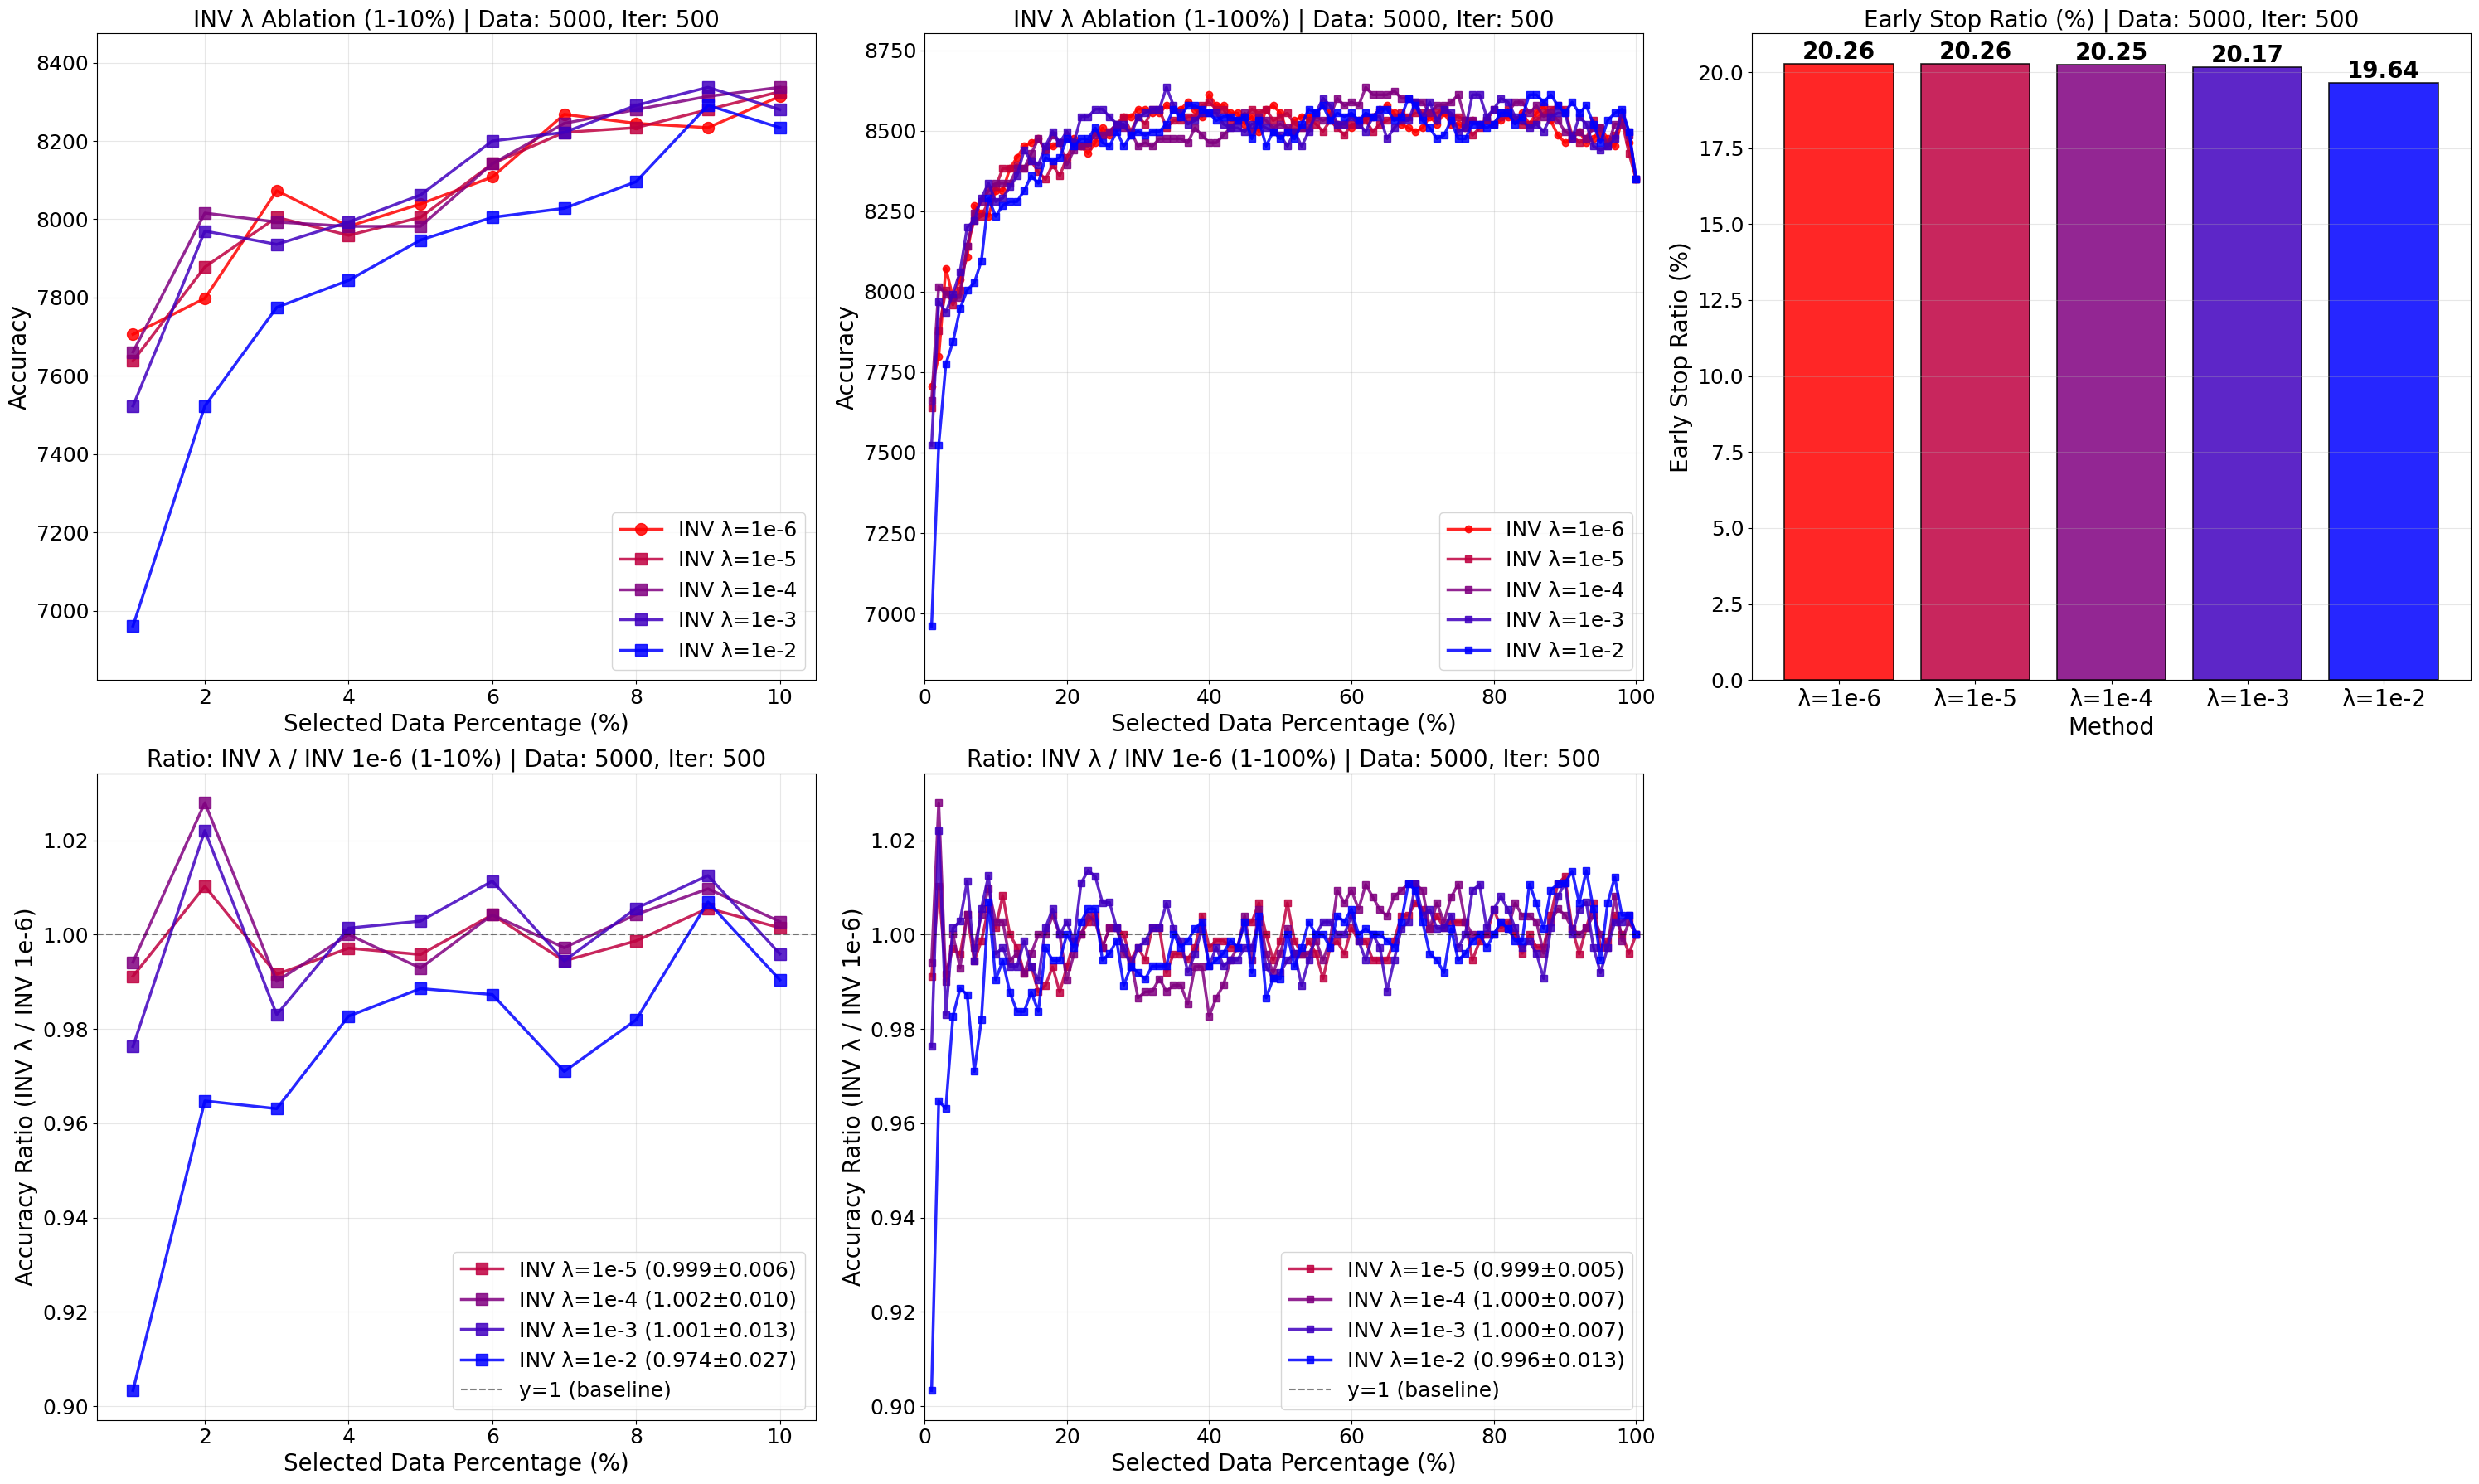

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 5000
iteration = 500
rank = 5
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [7706, 7798, 8073, 7982, 8039, 8108, 8268, 8245, 8234, 8314, 8314, 8383, 8417, 8452, 8463, 8475, 8440, 8452, 8463, 8475, 8475, 8452, 8429, 8463, 8509, 8486, 8509, 8544, 8544, 8567, 8567, 8555, 8555, 8578, 8567, 8567, 8589, 8567, 8544, 8612, 8578, 8578, 8555, 8555, 8521, 8544, 8498, 8567, 8578, 8555, 8498, 8532, 8544, 8544, 8555, 8578, 8555, 8521, 8521, 8509, 8532, 8544, 8544, 8567, 8578, 8555, 8521, 8509, 8498, 8509, 8544, 8521, 8555, 8521, 8521, 8509, 8532, 8521, 8532, 8521, 8532, 8544, 8532, 8555, 8521, 8555, 8578, 8532, 8486, 8463, 8475, 8498, 8463, 8475, 8509, 8475, 8452, 8532, 8463, 8349]
lam1e_5  = [7638, 7878, 8005, 7959, 8005, 8142, 8222, 8234, 8280, 8326, 8383, 8383, 8394, 8383, 8406, 8372, 8349, 8394, 8360, 8417, 8463, 8452, 8452, 8498, 8486, 8498, 8521, 8544, 8498, 8544, 8521, 8567, 8567, 8509, 8532, 8532, 8544, 8544, 8578, 8589, 8567, 8567, 8532, 8532, 8544, 8567, 8555, 8567, 8532, 8544, 8555, 8521, 8509, 8532, 8521, 8498, 8532, 8509, 8486, 8521, 8521, 8532, 8498, 8521, 8532, 8544, 8555, 8544, 8555, 8555, 8555, 8555, 8567, 8544, 8544, 8532, 8486, 8509, 8532, 8567, 8544, 8567, 8532, 8521, 8521, 8532, 8555, 8567, 8578, 8567, 8486, 8463, 8475, 8532, 8486, 8463, 8486, 8532, 8429, 8349]
lam1e_4  = [7661, 8016, 7993, 7982, 7982, 8142, 8245, 8280, 8314, 8337, 8337, 8337, 8383, 8383, 8429, 8475, 8440, 8486, 8463, 8394, 8440, 8452, 8463, 8486, 8486, 8498, 8521, 8509, 8498, 8452, 8463, 8452, 8475, 8475, 8475, 8475, 8463, 8509, 8486, 8463, 8463, 8486, 8509, 8532, 8555, 8498, 8544, 8532, 8509, 8521, 8509, 8498, 8509, 8509, 8544, 8532, 8544, 8601, 8578, 8589, 8578, 8635, 8612, 8612, 8612, 8624, 8601, 8601, 8589, 8589, 8555, 8578, 8578, 8589, 8612, 8532, 8532, 8521, 8532, 8521, 8555, 8555, 8589, 8589, 8555, 8578, 8544, 8555, 8532, 8498, 8486, 8498, 8475, 8509, 8509, 8452, 8521, 8521, 8486, 8349]
lam1e_3  = [7523, 7970, 7936, 7993, 8062, 8200, 8222, 8291, 8337, 8280, 8291, 8326, 8360, 8440, 8406, 8394, 8452, 8498, 8463, 8498, 8463, 8544, 8544, 8567, 8567, 8544, 8521, 8521, 8486, 8544, 8555, 8567, 8567, 8635, 8578, 8555, 8521, 8532, 8555, 8555, 8555, 8521, 8509, 8509, 8498, 8521, 8521, 8509, 8498, 8486, 8452, 8498, 8452, 8498, 8555, 8601, 8578, 8521, 8521, 8544, 8521, 8498, 8544, 8544, 8475, 8509, 8532, 8532, 8589, 8544, 8589, 8532, 8567, 8555, 8498, 8509, 8612, 8612, 8544, 8567, 8601, 8589, 8544, 8532, 8509, 8521, 8498, 8544, 8555, 8555, 8475, 8544, 8521, 8452, 8440, 8452, 8475, 8555, 8498, 8349]
lam1e_2  = [6961, 7523, 7775, 7844, 7947, 8005, 8028, 8096, 8291, 8234, 8268, 8280, 8280, 8314, 8360, 8337, 8417, 8406, 8417, 8475, 8452, 8475, 8475, 8509, 8463, 8452, 8498, 8452, 8486, 8498, 8486, 8498, 8498, 8521, 8567, 8544, 8578, 8578, 8567, 8555, 8532, 8544, 8544, 8532, 8544, 8475, 8532, 8452, 8498, 8475, 8498, 8475, 8521, 8567, 8555, 8578, 8532, 8555, 8544, 8555, 8532, 8555, 8544, 8567, 8567, 8532, 8544, 8601, 8578, 8532, 8509, 8475, 8486, 8532, 8475, 8475, 8521, 8521, 8509, 8521, 8555, 8555, 8521, 8544, 8612, 8612, 8589, 8612, 8578, 8555, 8589, 8555, 8578, 8521, 8463, 8532, 8555, 8567, 8498, 8349]

lam1e_6_early_stop = [20.26]
lam1e_5_early_stop = [20.26]
lam1e_4_early_stop = [20.25]
lam1e_3_early_stop = [20.17]
lam1e_2_early_stop = [19.64]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 10000
iteration = 500
rank = 5
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()